
PRESSURE SENSITIVITY ANALYSIS
    Pressure_bar  Ethanol_Liquid_kmol_h  CO2_Vapor_kmol_h  \
0       1.000000              87.913830         98.934947   
1       1.039039              88.421890         98.881377   
2       1.078078              88.889078         98.827755   
3       1.117117              89.320136         98.774080   
4       1.156156              89.719102         98.720353   
5       1.195195              90.089430         98.666572   
6       1.234234              90.434098         98.612739   
7       1.273273              90.755684         98.558852   
8       1.312312              91.056433         98.504912   
9       1.351351              91.338307         98.450919   
10      1.390390              91.603029         98.396873   
11      1.429429              91.852119         98.342773   
12      1.468468              92.086923         98.288620   
13      1.507508              92.308636         98.234413   
14      1.546547              92.518323         98.180

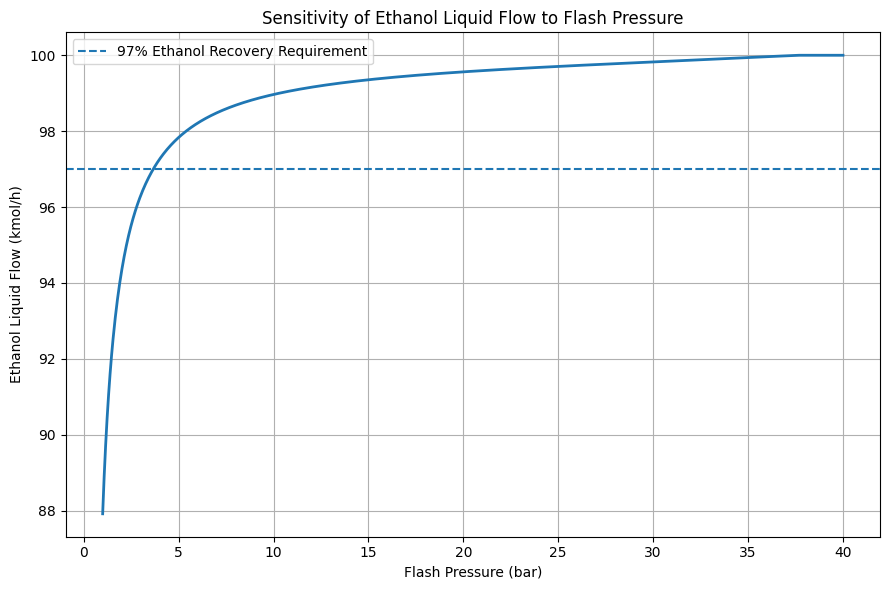

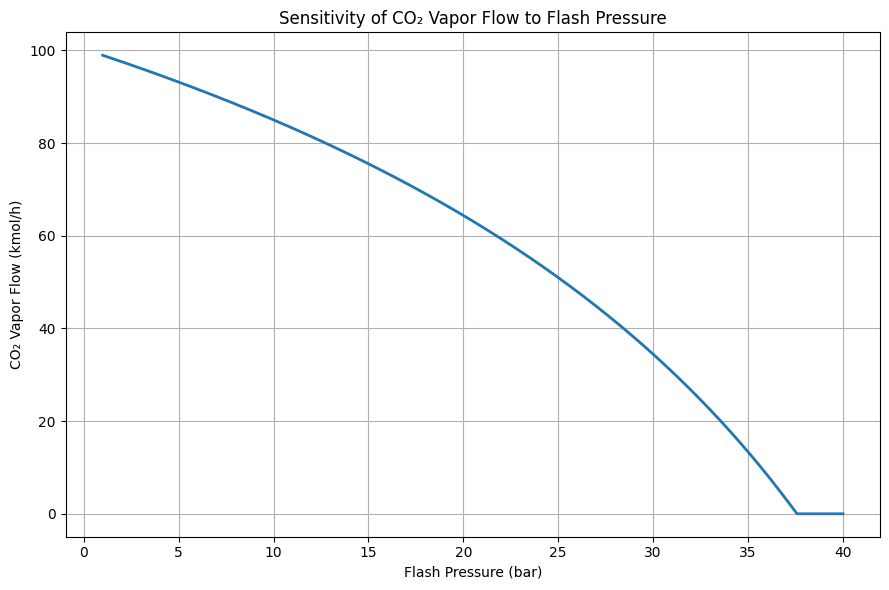

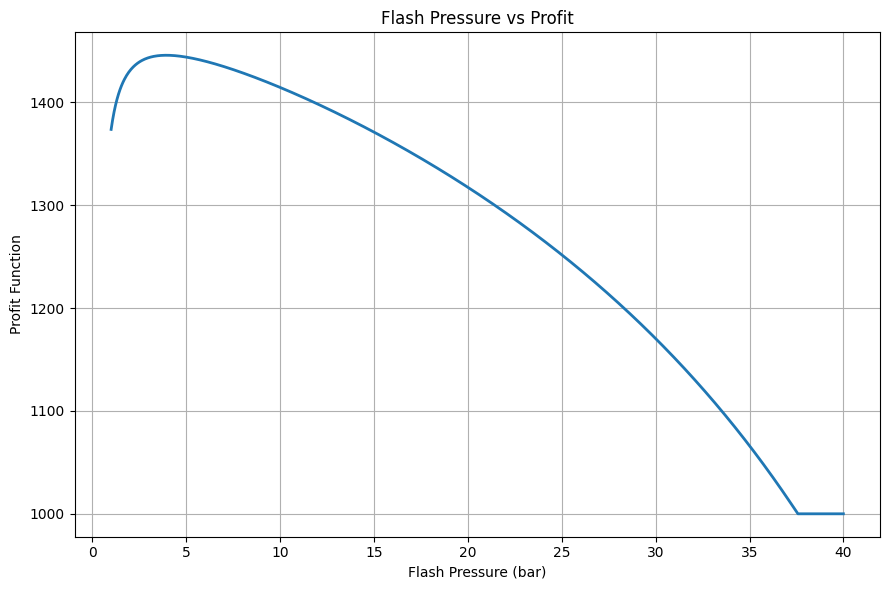


BEST FEASIBLE POINT FROM 1000-POINT PRESSURE SEARCH
Flash Pressure       : 3.9279 bar
Ethanol Liquid       : 97.2093 kmol/h
CO2 Vapor             : 94.7651 kmol/h
Ethanol Recovery     : 97.2093 %
CO2 Recovery         : 94.7651 %
Profit                : 1445.9188


FINAL FLASH PRESSURE OPTIMIZATION
Optimum Flash Pressure       : 3.93834 bar
Vapor Flow                   : 97.53264 kmol/h
Liquid Flow                  : 102.46736 kmol/h
Ethanol in Liquid            : 97.21706 kmol/h
Ethanol in Vapor             : 2.78294 kmol/h
CO2 in Liquid                : 5.25031 kmol/h
CO2 in Vapor                 : 94.74969 kmol/h
Ethanol Liquid Mole Fraction : 0.94876
CO2 Vapor Mole Fraction      : 0.97147
Ethanol Recovery             : 97.21706 %
CO2 Vapor Recovery           : 94.74969 %
Maximum Profit               : 1445.91904

CONSTRAINT VERIFICATION
Ethanol recovery constraint: SATISFIED

Optimum result saved as:
ethanol_CO2_flash_optimum_result.csv


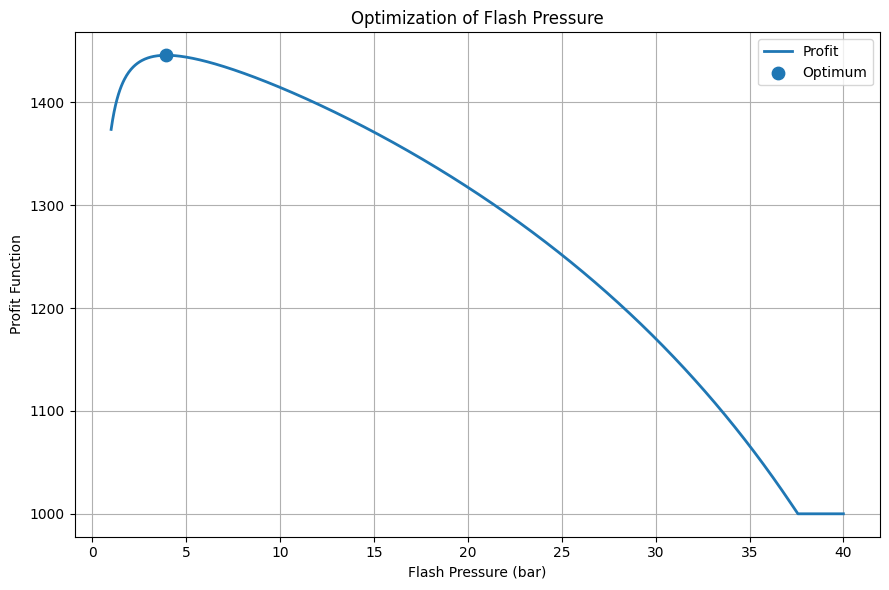

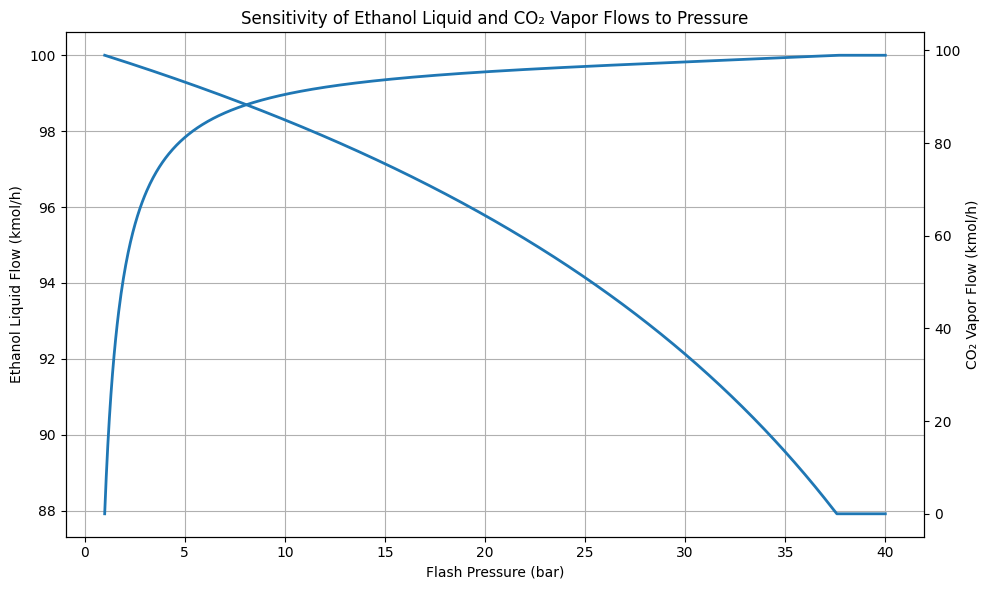


FINAL SUMMARY
               Parameter           Value
               Feed Flow      200 kmol/h
            Feed Ethanol      100 kmol/h
                Feed CO2      100 kmol/h
        Feed Temperature           30 °C
           Feed Pressure          50 bar
       Flash Temperature           30 °C
Optimized Flash Pressure     3.93834 bar
     Ethanol Liquid Flow 97.21706 kmol/h
          CO2 Vapor Flow 94.74969 kmol/h
        Ethanol Recovery      97.21706 %
            CO2 Recovery      94.74969 %
          Maximum Profit      1445.91904

All optimization and sensitivity results completed.


In [ ]:
# ============================================================
# ETHANOL–CO2 FLASH SEPARATION
# Pressure Sensitivity + Profit Optimization
#
# Feed:
#   Total flow       = 200 kmol/h
#   Ethanol          = 100 kmol/h
#   CO2              = 100 kmol/h
#   Feed temperature = 30 °C
#   Feed pressure    = 50 bar
#
# Flash:
#   Temperature      = 30 °C
#   Pressure         = 1–40 bar
#
# Objective:
#   MAX Profit = 10*(Ethanol liquid flow)
#              + 5*(CO2 vapor flow)
#
# Constraint:
#   Ethanol recovery in liquid >= 97%
#
# Thermodynamics:
#   Peng–Robinson EOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize_scalar


# ============================================================
# 1. COMPONENT DATA
# ============================================================

R = 8.314462618          # J/mol/K
T = 30.0 + 273.15       # K

components = ["Ethanol", "CO2"]

# Critical properties
Tc = np.array([
    514.0,       # Ethanol, K
    304.1282     # CO2, K
])

Pc = np.array([
    61.37,       # Ethanol, bar
    73.773       # CO2, bar
])

omega = np.array([
    0.644,       # Ethanol
    0.22394      # CO2
])

# Convert pressure from bar to Pa
Pc_Pa = Pc * 1e5

# Binary interaction parameter
# Can be replaced by experimentally validated Aspen/HYSYS value
Kij = np.array([
    [0.0, 0.0],
    [0.0, 0.0]
])


# ============================================================
# 2. PENG–ROBINSON EOS PARAMETERS
# ============================================================

def PR_parameters(T):

    Tr = T / Tc

    kappa = (
        0.37464
        + 1.54226 * omega
        - 0.26992 * omega**2
    )

    alpha = (
        1
        + kappa * (1 - np.sqrt(Tr))
    )**2

    a = (
        0.45724
        * R**2
        * Tc**2
        / Pc_Pa
        * alpha
    )

    b = (
        0.07780
        * R
        * Tc
        / Pc_Pa
    )

    return a, b


a_i, b_i = PR_parameters(T)


# ============================================================
# 3. MIXTURE PARAMETERS
# ============================================================

def mixture_parameters(x):

    a_mix = 0.0

    for i in range(2):
        for j in range(2):
            a_ij = np.sqrt(a_i[i] * a_i[j])
            a_ij *= (1.0 - Kij[i, j])

            a_mix += x[i] * x[j] * a_ij

    b_mix = np.sum(x * b_i)

    return a_mix, b_mix


# ============================================================
# 4. PR COMPRESSIBILITY FACTOR
# ============================================================

def PR_Z_factor(P_bar, x, phase="vapor"):

    P = P_bar * 1e5

    a_mix, b_mix = mixture_parameters(x)

    A = a_mix * P / (R**2 * T**2)
    B = b_mix * P / (R * T)

    coeff = [
        1.0,
        -(1.0 - B),
        A - 3.0 * B**2 - 2.0 * B,
        -(A * B - B**2 - B**3)
    ]

    roots = np.roots(coeff)

    real_roots = np.real(
        roots[np.abs(np.imag(roots)) < 1e-8]
    )

    real_roots = real_roots[real_roots > B]

    if len(real_roots) == 0:
        return 1.0

    if phase.lower() == "liquid":
        return np.min(real_roots)
    else:
        return np.max(real_roots)


# ============================================================
# 5. FUGACITY COEFFICIENT
# ============================================================

def fugacity_coefficients(P_bar, x, phase="vapor"):

    P = P_bar * 1e5

    a_mix, b_mix = mixture_parameters(x)

    A = a_mix * P / (R**2 * T**2)
    B = b_mix * P / (R * T)

    Z = PR_Z_factor(P_bar, x, phase)

    phi = np.zeros(2)

    for i in range(2):

        sum_aij = 0.0

        for j in range(2):
            a_ij = np.sqrt(a_i[i] * a_i[j])
            a_ij *= (1.0 - Kij[i, j])

            sum_aij += x[j] * a_ij

        term1 = (
            b_i[i] / b_mix
            * (Z - 1.0)
        )

        term2 = -np.log(Z - B)

        term3 = (
            A / (2.0 * np.sqrt(2.0) * B)
        )

        term4 = (
            2.0 * sum_aij / a_mix
            - b_i[i] / b_mix
        )

        term5 = np.log(
            (Z + (1.0 + np.sqrt(2.0)) * B)
            /
            (Z + (1.0 - np.sqrt(2.0)) * B)
        )

        ln_phi = (
            term1
            + term2
            - term3 * term4 * term5
        )

        phi[i] = np.exp(ln_phi)

    return phi


# ============================================================
# 6. INITIAL K-VALUE ESTIMATE
# ============================================================

def initial_K_values(P_bar):

    # Wilson-type estimate
    K = (
        Pc / P_bar
        * np.exp(
            5.373
            * (1.0 + omega)
            * (1.0 - Tc / T)
        )
    )

    return np.clip(K, 1e-6, 1e6)


# ============================================================
# 7. RACHFORD–RICE EQUATION
# ============================================================

def rachford_rice(beta, z, K):

    return np.sum(
        z * (K - 1.0)
        /
        (1.0 + beta * (K - 1.0))
    )


def vapor_fraction(z, K):

    f0 = rachford_rice(0.0, z, K)
    f1 = rachford_rice(1.0, z, K)

    # All liquid
    if f0 < 0.0:
        return 0.0

    # All vapor
    if f1 > 0.0:
        return 1.0

    low = 0.0
    high = 1.0

    for _ in range(100):

        mid = 0.5 * (low + high)

        f = rachford_rice(mid, z, K)

        if f > 0:
            low = mid
        else:
            high = mid

    return 0.5 * (low + high)


# ============================================================
# 8. FLASH CALCULATION
# ============================================================

def flash_calculation(P_bar):

    z = np.array([0.50, 0.50])

    K = initial_K_values(P_bar)

    beta = 0.5

    for iteration in range(100):

        beta = vapor_fraction(z, K)

        # Single-phase liquid
        if beta <= 1e-8:

            x = z.copy()
            y = K * x
            y = y / np.sum(y)

            phi_L = fugacity_coefficients(
                P_bar, x, "liquid"
            )

            phi_V = fugacity_coefficients(
                P_bar, y, "vapor"
            )

            K_new = phi_L / phi_V

        # Single-phase vapor
        elif beta >= 1.0 - 1e-8:

            y = z.copy()
            x = z / K
            x = x / np.sum(x)

            phi_L = fugacity_coefficients(
                P_bar, x, "liquid"
            )

            phi_V = fugacity_coefficients(
                P_bar, y, "vapor"
            )

            K_new = phi_L / phi_V

        # Two-phase region
        else:

            x = z / (
                1.0 + beta * (K - 1.0)
            )

            y = K * x

            x = x / np.sum(x)
            y = y / np.sum(y)

            phi_L = fugacity_coefficients(
                P_bar, x, "liquid"
            )

            phi_V = fugacity_coefficients(
                P_bar, y, "vapor"
            )

            K_new = phi_L / phi_V

        # Damping for numerical stability
        K_updated = (
            0.5 * K
            + 0.5 * K_new
        )

        error = np.max(
            np.abs(
                np.log(K_updated / K)
            )
        )

        K = K_updated

        if error < 1e-7:
            break

    # Final phase calculations
    beta = vapor_fraction(z, K)

    if beta <= 1e-8:

        beta = 0.0
        L = 200.0
        V = 0.0

        x = z.copy()
        y = np.array([0.0, 0.0])

    elif beta >= 1.0 - 1e-8:

        beta = 1.0
        L = 0.0
        V = 200.0

        y = z.copy()
        x = np.array([0.0, 0.0])

    else:

        V = 200.0 * beta
        L = 200.0 * (1.0 - beta)

        x = z / (
            1.0 + beta * (K - 1.0)
        )

        y = K * x

        x = x / np.sum(x)
        y = y / np.sum(y)

    # Component flow rates
    ethanol_liquid = L * x[0]
    ethanol_vapor = V * y[0]

    co2_liquid = L * x[1]
    co2_vapor = V * y[1]

    # Ethanol liquid recovery
    ethanol_recovery = (
        ethanol_liquid / 100.0
        * 100.0
    )

    # CO2 vapor recovery
    co2_recovery = (
        co2_vapor / 100.0
        * 100.0
    )

    # Profit function
    profit = (
        10.0 * ethanol_liquid
        + 5.0 * co2_vapor
    )

    return {
        "Pressure_bar": P_bar,
        "Vapor_Flow_kmol_h": V,
        "Liquid_Flow_kmol_h": L,
        "Ethanol_Liquid_kmol_h": ethanol_liquid,
        "Ethanol_Vapor_kmol_h": ethanol_vapor,
        "CO2_Liquid_kmol_h": co2_liquid,
        "CO2_Vapor_kmol_h": co2_vapor,
        "Ethanol_Liquid_mol_frac": x[0],
        "Ethanol_Vapor_mol_frac": y[0],
        "CO2_Liquid_mol_frac": x[1],
        "CO2_Vapor_mol_frac": y[1],
        "Ethanol_Recovery_percent": ethanol_recovery,
        "CO2_Recovery_percent": co2_recovery,
        "Profit": profit
    }


# ============================================================
# 9. SENSITIVITY ANALYSIS
#    1000 PRESSURE DATA POINTS
# ============================================================

pressure_data = np.linspace(
    1.0,
    40.0,
    1000
)

results = []

for P in pressure_data:

    try:

        result = flash_calculation(P)

        results.append(result)

    except Exception:

        results.append({
            "Pressure_bar": P,
            "Vapor_Flow_kmol_h": np.nan,
            "Liquid_Flow_kmol_h": np.nan,
            "Ethanol_Liquid_kmol_h": np.nan,
            "Ethanol_Vapor_kmol_h": np.nan,
            "CO2_Liquid_kmol_h": np.nan,
            "CO2_Vapor_kmol_h": np.nan,
            "Ethanol_Liquid_mol_frac": np.nan,
            "Ethanol_Vapor_mol_frac": np.nan,
            "CO2_Liquid_mol_frac": np.nan,
            "CO2_Vapor_mol_frac": np.nan,
            "Ethanol_Recovery_percent": np.nan,
            "CO2_Recovery_percent": np.nan,
            "Profit": np.nan
        })


df = pd.DataFrame(results)


# ============================================================
# 10. DISPLAY SENSITIVITY DATA
# ============================================================

print("\n============================================================")
print("PRESSURE SENSITIVITY ANALYSIS")
print("============================================================")

print(
    df[
        [
            "Pressure_bar",
            "Ethanol_Liquid_kmol_h",
            "CO2_Vapor_kmol_h",
            "Ethanol_Recovery_percent",
            "Profit"
        ]
    ].head(20)
)


# ============================================================
# 11. SAVE 1000-POINT DATASET
# ============================================================

df.to_csv(
    "ethanol_CO2_flash_1000_point_sensitivity.csv",
    index=False
)

print(
    "\n1000-point sensitivity dataset saved as:"
)

print(
    "ethanol_CO2_flash_1000_point_sensitivity.csv"
)


# ============================================================
# 12. PLOT ETHANOL LIQUID FLOW VS PRESSURE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df["Pressure_bar"],
    df["Ethanol_Liquid_kmol_h"],
    linewidth=2
)

plt.axhline(
    97.0,
    linestyle="--",
    linewidth=1.5,
    label="97% Ethanol Recovery Requirement"
)

plt.xlabel("Flash Pressure (bar)")
plt.ylabel("Ethanol Liquid Flow (kmol/h)")
plt.title(
    "Sensitivity of Ethanol Liquid Flow to Flash Pressure"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. PLOT CO2 VAPOR FLOW VS PRESSURE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df["Pressure_bar"],
    df["CO2_Vapor_kmol_h"],
    linewidth=2
)

plt.xlabel("Flash Pressure (bar)")
plt.ylabel("CO₂ Vapor Flow (kmol/h)")
plt.title(
    "Sensitivity of CO₂ Vapor Flow to Flash Pressure"
)

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 14. PLOT PROFIT VS PRESSURE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df["Pressure_bar"],
    df["Profit"],
    linewidth=2
)

plt.xlabel("Flash Pressure (bar)")
plt.ylabel("Profit Function")
plt.title(
    "Flash Pressure vs Profit"
)

plt.grid(True)
plt.tight_layout()
plt.show()


# ============================================================
# 15. APPLY ETHANOL RECOVERY CONSTRAINT
# ============================================================

feasible = df[
    df["Ethanol_Recovery_percent"] >= 97.0
].copy()

feasible = feasible.dropna(
    subset=["Profit"]
)


# ============================================================
# 16. FIND BEST PRESSURE FROM 1000-POINT DATA
# ============================================================

if len(feasible) == 0:

    print(
        "\nNo flash pressure between 1 and 40 bar "
        "satisfies the 97% ethanol-liquid-recovery constraint."
    )

else:

    best_grid = feasible.loc[
        feasible["Profit"].idxmax()
    ]

    print("\n============================================================")
    print("BEST FEASIBLE POINT FROM 1000-POINT PRESSURE SEARCH")
    print("============================================================")

    print(
        f"Flash Pressure       : "
        f"{best_grid['Pressure_bar']:.4f} bar"
    )

    print(
        f"Ethanol Liquid       : "
        f"{best_grid['Ethanol_Liquid_kmol_h']:.4f} kmol/h"
    )

    print(
        f"CO2 Vapor             : "
        f"{best_grid['CO2_Vapor_kmol_h']:.4f} kmol/h"
    )

    print(
        f"Ethanol Recovery     : "
        f"{best_grid['Ethanol_Recovery_percent']:.4f} %"
    )

    print(
        f"CO2 Recovery         : "
        f"{best_grid['CO2_Recovery_percent']:.4f} %"
    )

    print(
        f"Profit                : "
        f"{best_grid['Profit']:.4f}"
    )


# ============================================================
# 17. CONTINUOUS PRESSURE OPTIMIZATION
# ============================================================
# A penalty function is used when ethanol recovery is below 97%.

def objective(P):

    result = flash_calculation(float(P))

    profit = result["Profit"]

    recovery = result[
        "Ethanol_Recovery_percent"
    ]

    if recovery < 97.0:

        penalty = (
            1e6
            * (97.0 - recovery)**2
        )

        return -profit + penalty

    return -profit


optimization = minimize_scalar(
    objective,
    bounds=(1.0, 40.0),
    method="bounded",
    options={
        "xatol": 1e-5,
        "maxiter": 500
    }
)


# ============================================================
# 18. FINAL OPTIMUM
# ============================================================

P_opt = optimization.x

optimum = flash_calculation(
    P_opt
)


# ============================================================
# 19. FINAL OPTIMIZATION RESULTS
# ============================================================

print("\n\n============================================================")
print("FINAL FLASH PRESSURE OPTIMIZATION")
print("============================================================")

print(
    f"Optimum Flash Pressure       : "
    f"{P_opt:.5f} bar"
)

print(
    f"Vapor Flow                   : "
    f"{optimum['Vapor_Flow_kmol_h']:.5f} kmol/h"
)

print(
    f"Liquid Flow                  : "
    f"{optimum['Liquid_Flow_kmol_h']:.5f} kmol/h"
)

print(
    f"Ethanol in Liquid            : "
    f"{optimum['Ethanol_Liquid_kmol_h']:.5f} kmol/h"
)

print(
    f"Ethanol in Vapor             : "
    f"{optimum['Ethanol_Vapor_kmol_h']:.5f} kmol/h"
)

print(
    f"CO2 in Liquid                : "
    f"{optimum['CO2_Liquid_kmol_h']:.5f} kmol/h"
)

print(
    f"CO2 in Vapor                 : "
    f"{optimum['CO2_Vapor_kmol_h']:.5f} kmol/h"
)

print(
    f"Ethanol Liquid Mole Fraction : "
    f"{optimum['Ethanol_Liquid_mol_frac']:.5f}"
)

print(
    f"CO2 Vapor Mole Fraction      : "
    f"{optimum['CO2_Vapor_mol_frac']:.5f}"
)

print(
    f"Ethanol Recovery             : "
    f"{optimum['Ethanol_Recovery_percent']:.5f} %"
)

print(
    f"CO2 Vapor Recovery           : "
    f"{optimum['CO2_Recovery_percent']:.5f} %"
)

print(
    f"Maximum Profit               : "
    f"{optimum['Profit']:.5f}"
)


# ============================================================
# 20. VERIFY CONSTRAINT
# ============================================================

print("\n============================================================")
print("CONSTRAINT VERIFICATION")
print("============================================================")

if optimum["Ethanol_Recovery_percent"] >= 97.0:

    print(
        "Ethanol recovery constraint: SATISFIED"
    )

else:

    print(
        "Ethanol recovery constraint: NOT SATISFIED"
    )


# ============================================================
# 21. SAVE OPTIMUM RESULT
# ============================================================

optimum_df = pd.DataFrame(
    [optimum]
)

optimum_df.to_csv(
    "ethanol_CO2_flash_optimum_result.csv",
    index=False
)

print(
    "\nOptimum result saved as:"
)

print(
    "ethanol_CO2_flash_optimum_result.csv"
)


# ============================================================
# 22. MARK OPTIMUM ON PROFIT CURVE
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    df["Pressure_bar"],
    df["Profit"],
    linewidth=2,
    label="Profit"
)

plt.scatter(
    P_opt,
    optimum["Profit"],
    s=80,
    label="Optimum"
)

plt.xlabel("Flash Pressure (bar)")
plt.ylabel("Profit Function")
plt.title(
    "Optimization of Flash Pressure"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 23. COMBINED SENSITIVITY PLOT
# ============================================================

fig, ax1 = plt.subplots(
    figsize=(10, 6)
)

ax1.plot(
    df["Pressure_bar"],
    df["Ethanol_Liquid_kmol_h"],
    linewidth=2,
    label="Ethanol in Liquid"
)

ax1.set_xlabel(
    "Flash Pressure (bar)"
)

ax1.set_ylabel(
    "Ethanol Liquid Flow (kmol/h)"
)

ax2 = ax1.twinx()

ax2.plot(
    df["Pressure_bar"],
    df["CO2_Vapor_kmol_h"],
    linewidth=2,
    label="CO₂ in Vapor"
)

ax2.set_ylabel(
    "CO₂ Vapor Flow (kmol/h)"
)

plt.title(
    "Sensitivity of Ethanol Liquid and CO₂ Vapor Flows to Pressure"
)

ax1.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 24. FINAL SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "Parameter": [
        "Feed Flow",
        "Feed Ethanol",
        "Feed CO2",
        "Feed Temperature",
        "Feed Pressure",
        "Flash Temperature",
        "Optimized Flash Pressure",
        "Ethanol Liquid Flow",
        "CO2 Vapor Flow",
        "Ethanol Recovery",
        "CO2 Recovery",
        "Maximum Profit"
    ],

    "Value": [
        "200 kmol/h",
        "100 kmol/h",
        "100 kmol/h",
        "30 °C",
        "50 bar",
        "30 °C",
        f"{P_opt:.5f} bar",
        f"{optimum['Ethanol_Liquid_kmol_h']:.5f} kmol/h",
        f"{optimum['CO2_Vapor_kmol_h']:.5f} kmol/h",
        f"{optimum['Ethanol_Recovery_percent']:.5f} %",
        f"{optimum['CO2_Recovery_percent']:.5f} %",
        f"{optimum['Profit']:.5f}"
    ]
})

print("\n============================================================")
print("FINAL SUMMARY")
print("============================================================")

print(
    summary.to_string(index=False)
)

summary.to_csv(
    "ethanol_CO2_flash_final_summary.csv",
    index=False
)

print(
    "\nAll optimization and sensitivity results completed."
)


INPUT DATA
   Pressure_bar  Vapor_Flow_kmol_h  Liquid_Flow_kmol_h  Ethanol_Liquid_kmol_h  \
0      1.000000         111.021117           88.978883              87.913830   
1      1.039039         110.459488           89.540512              88.421890   
2      1.078078         109.938677           90.061323              88.889078   
3      1.117117         109.453944           90.546056              89.320136   
4      1.156156         109.001251           90.998749              89.719102   

   Ethanol_Vapor_kmol_h  CO2_Liquid_kmol_h  CO2_Vapor_kmol_h  \
0             12.086170           1.065053         98.934947   
1             11.578110           1.118623         98.881377   
2             11.110922           1.172245         98.827755   
3             10.679864           1.225920         98.774080   
4             10.280898           1.279647         98.720353   

   Ethanol_Liquid_mol_frac  Ethanol_Vapor_mol_frac  CO2_Liquid_mol_frac  \
0                 0.988030               

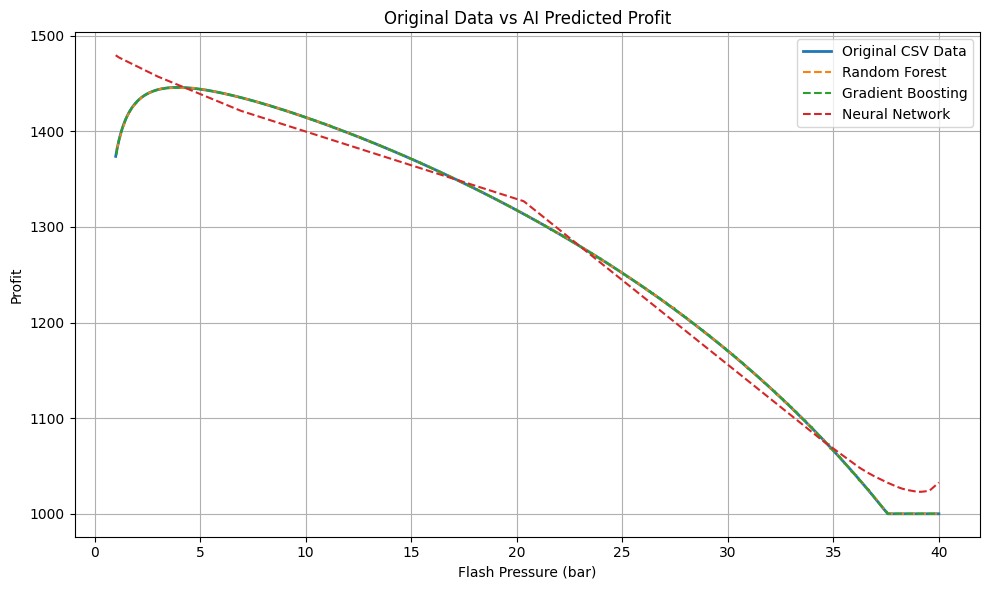

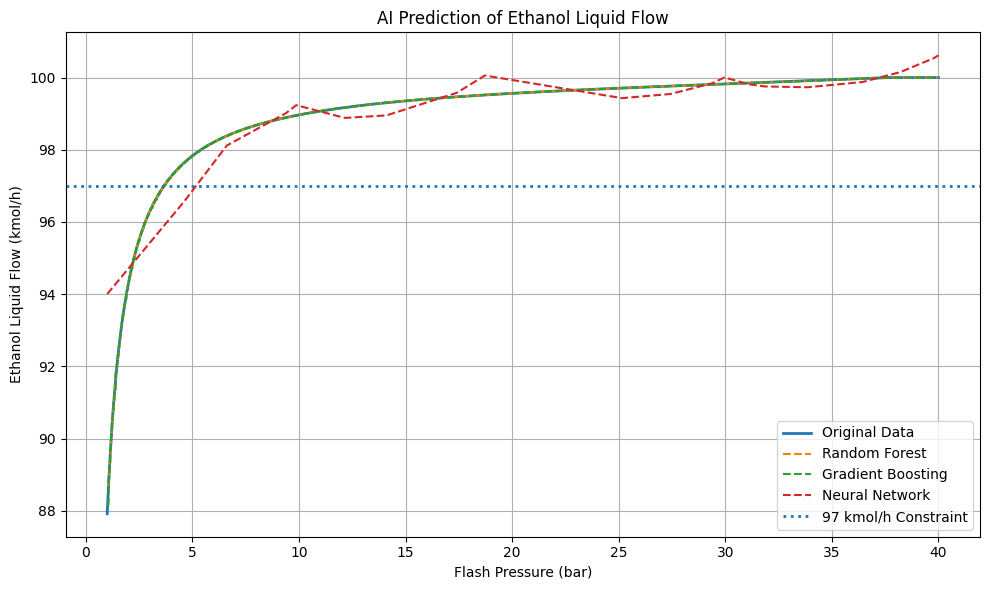

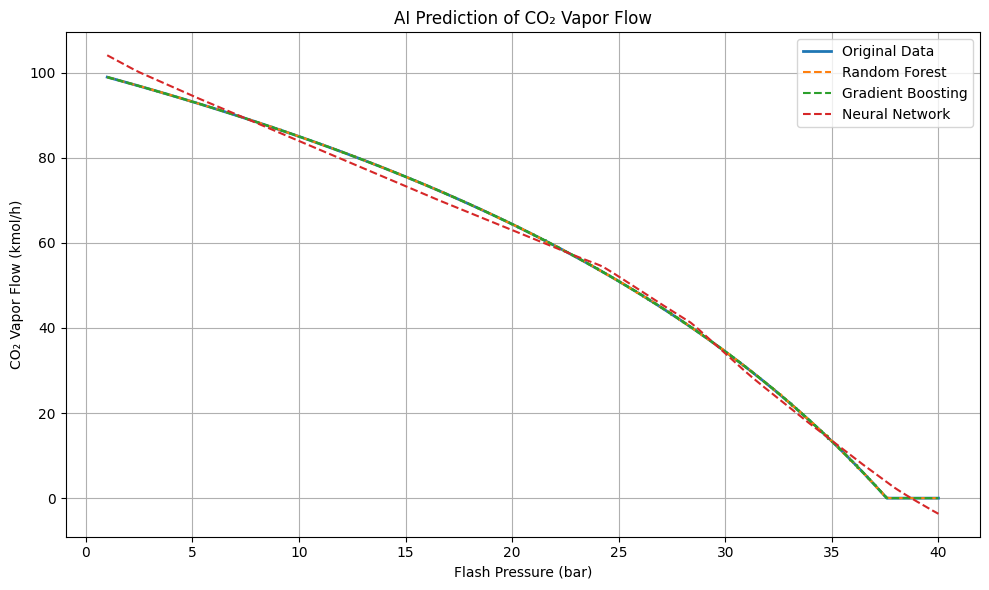

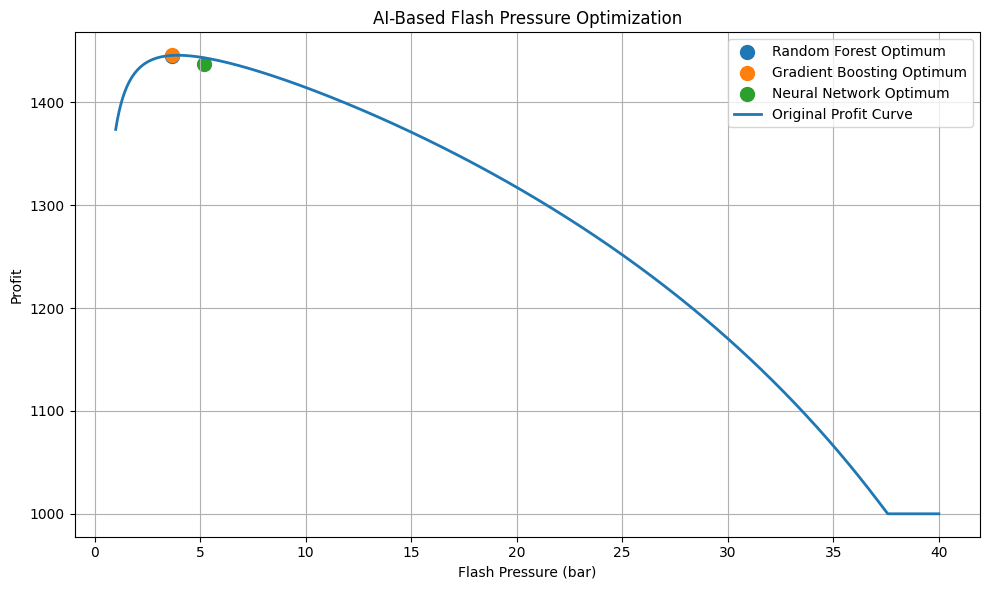


AI MODEL PERFORMANCE
            Model                   Output       R2      RMSE       MAE
    Random Forest    Ethanol_Liquid_kmol_h 0.999824  0.015579  0.004721
    Random Forest         CO2_Vapor_kmol_h 0.999992  0.085312  0.063084
    Random Forest Ethanol_Recovery_percent 0.999824  0.015579  0.004721
    Random Forest                   Profit 0.999990  0.453571  0.335951
Gradient Boosting    Ethanol_Liquid_kmol_h 0.999487  0.026591  0.008435
Gradient Boosting         CO2_Vapor_kmol_h 0.999986  0.112365  0.097200
Gradient Boosting Ethanol_Recovery_percent 0.999487  0.026591  0.008435
Gradient Boosting                   Profit 0.999984  0.585398  0.481644
   Neural Network    Ethanol_Liquid_kmol_h 0.866711  0.428754  0.288222
   Neural Network         CO2_Vapor_kmol_h 0.997015  1.662625  1.418625
   Neural Network Ethanol_Recovery_percent 0.866711  0.428754  0.288222
   Neural Network                   Profit 0.990267 14.287896 11.605631

FILES GENERATED
1. AI_flash_optimization_

In [ ]:
# ============================================================
# AI-BASED OPTIMIZATION OF ETHANOL–CO2 FLASH SEPARATION
# ============================================================
#
# INPUT FILE:
#   ethanol_CO2_flash_1000_point_sensitivity.csv
#
# AI / ML OPTIMIZATION METHODS:
#
#   1. Random Forest Regression
#   2. Gradient Boosting Regression
#   3. Artificial Neural Network (MLP)
#
# Objective:
#
#   MAX Profit =
#       10 × Ethanol Liquid Flow
#       + 5 × CO2 Vapor Flow
#
# Constraint:
#
#   Ethanol liquid recovery >= 97%
#
# Decision variable:
#
#   Flash Pressure = 1–40 bar
#
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# ============================================================
# 2. LOAD CSV DATA
# ============================================================

file_name = "ethanol_CO2_flash_1000_point_sensitivity.csv"

df = pd.read_csv(file_name)


# ============================================================
# 3. DISPLAY DATA
# ============================================================

print("\n============================================================")
print("INPUT DATA")
print("============================================================")

print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nAvailable columns:")
print(df.columns.tolist())


# ============================================================
# 4. CHECK REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Pressure_bar",
    "Ethanol_Liquid_kmol_h",
    "CO2_Vapor_kmol_h",
    "Ethanol_Recovery_percent",
    "Profit"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if len(missing_columns) > 0:

    raise ValueError(
        "Missing columns in CSV file: "
        + str(missing_columns)
    )


# ============================================================
# 5. CLEAN DATA
# ============================================================

df = df[
    required_columns
].copy()

df = df.dropna()

df = df.sort_values(
    "Pressure_bar"
)

df = df.reset_index(
    drop=True
)


print("\nClean dataset:")
print(df.shape)


# ============================================================
# 6. CREATE INPUT AND OUTPUT VARIABLES
# ============================================================

# AI input
X = df[
    ["Pressure_bar"]
]

# AI output
#
# We predict:
#
#   Ethanol liquid flow
#   CO2 vapor flow
#   Ethanol recovery
#   Profit
#
Y = df[
    [
        "Ethanol_Liquid_kmol_h",
        "CO2_Vapor_kmol_h",
        "Ethanol_Recovery_percent",
        "Profit"
    ]
]


# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 8. DEFINE AI MODELS
# ============================================================


# ------------------------------------------------------------
# MODEL 1: RANDOM FOREST
# ------------------------------------------------------------

rf_models = {}

for target in Y.columns:

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        Y_train[target]
    )

    rf_models[target] = model


# ------------------------------------------------------------
# MODEL 2: GRADIENT BOOSTING
# ------------------------------------------------------------

gb_models = {}

for target in Y.columns:

    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    )

    model.fit(
        X_train,
        Y_train[target]
    )

    gb_models[target] = model


# ------------------------------------------------------------
# MODEL 3: ARTIFICIAL NEURAL NETWORK
# ------------------------------------------------------------

mlp_models = {}

for target in Y.columns:

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),

        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                max_iter=3000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=42
            )
        )
    ])

    model.fit(
        X_train,
        Y_train[target]
    )

    mlp_models[target] = model


# ============================================================
# 9. MODEL PERFORMANCE
# ============================================================

def calculate_model_performance(
    models,
    model_name
):

    print("\n============================================================")
    print(model_name)
    print("============================================================")

    performance = []

    for target in Y.columns:

        prediction = models[target].predict(
            X_test
        )

        r2 = r2_score(
            Y_test[target],
            prediction
        )

        rmse = np.sqrt(
            mean_squared_error(
                Y_test[target],
                prediction
            )
        )

        mae = mean_absolute_error(
            Y_test[target],
            prediction
        )

        performance.append([
            target,
            r2,
            rmse,
            mae
        ])

        print(
            f"{target:35s} "
            f"R² = {r2:.6f}   "
            f"RMSE = {rmse:.6f}   "
            f"MAE = {mae:.6f}"
        )

    return performance


rf_performance = calculate_model_performance(
    rf_models,
    "RANDOM FOREST PERFORMANCE"
)

gb_performance = calculate_model_performance(
    gb_models,
    "GRADIENT BOOSTING PERFORMANCE"
)

mlp_performance = calculate_model_performance(
    mlp_models,
    "NEURAL NETWORK PERFORMANCE"
)


# ============================================================
# 10. CREATE PRESSURE SEARCH GRID
# ============================================================
#
# Instead of optimizing only over the original 1000 points,
# generate a much finer pressure grid.
#
# 20,000 candidate pressure values are evaluated by
# the AI surrogate models.
# ============================================================

pressure_grid = np.linspace(
    1.0,
    40.0,
    20000
)

X_grid = pd.DataFrame({
    "Pressure_bar": pressure_grid
})


# ============================================================
# 11. AI OPTIMIZATION FUNCTION
# ============================================================

def optimize_with_ai(
    models,
    model_name
):

    # --------------------------------------------------------
    # Predict process variables
    # --------------------------------------------------------

    ethanol_liquid = models[
        "Ethanol_Liquid_kmol_h"
    ].predict(
        X_grid
    )

    co2_vapor = models[
        "CO2_Vapor_kmol_h"
    ].predict(
        X_grid
    )

    ethanol_recovery = models[
        "Ethanol_Recovery_percent"
    ].predict(
        X_grid
    )

    profit = models[
        "Profit"
    ].predict(
        X_grid
    )

    # --------------------------------------------------------
    # Create prediction dataframe
    # --------------------------------------------------------

    prediction = pd.DataFrame({

        "Pressure_bar":
            pressure_grid,

        "Predicted_Ethanol_Liquid_kmol_h":
            ethanol_liquid,

        "Predicted_CO2_Vapor_kmol_h":
            co2_vapor,

        "Predicted_Ethanol_Recovery_percent":
            ethanol_recovery,

        "Predicted_Profit":
            profit
    })


    # --------------------------------------------------------
    # Apply ethanol recovery constraint
    # --------------------------------------------------------

    feasible = prediction[
        prediction[
            "Predicted_Ethanol_Recovery_percent"
        ] >= 97.0
    ].copy()


    # --------------------------------------------------------
    # Find maximum predicted profit
    # --------------------------------------------------------

    if len(feasible) == 0:

        print(
            f"\n{model_name}: "
            "No feasible solution found."
        )

        return None, prediction

    optimum = feasible.loc[
        feasible[
            "Predicted_Profit"
        ].idxmax()
    ]


    # --------------------------------------------------------
    # Print optimum
    # --------------------------------------------------------

    print("\n============================================================")
    print(model_name)
    print("============================================================")

    print(
        f"Optimal Flash Pressure       : "
        f"{optimum['Pressure_bar']:.6f} bar"
    )

    print(
        f"Predicted Ethanol Liquid    : "
        f"{optimum['Predicted_Ethanol_Liquid_kmol_h']:.6f} "
        f"kmol/h"
    )

    print(
        f"Predicted CO2 Vapor         : "
        f"{optimum['Predicted_CO2_Vapor_kmol_h']:.6f} "
        f"kmol/h"
    )

    print(
        f"Predicted Ethanol Recovery  : "
        f"{optimum['Predicted_Ethanol_Recovery_percent']:.6f} %"
    )

    print(
        f"Predicted Maximum Profit    : "
        f"{optimum['Predicted_Profit']:.6f}"
    )

    return optimum, prediction


# ============================================================
# 12. OPTIMIZE USING RANDOM FOREST
# ============================================================

rf_optimum, rf_prediction = optimize_with_ai(
    rf_models,
    "RANDOM FOREST OPTIMIZATION"
)


# ============================================================
# 13. OPTIMIZE USING GRADIENT BOOSTING
# ============================================================

gb_optimum, gb_prediction = optimize_with_ai(
    gb_models,
    "GRADIENT BOOSTING OPTIMIZATION"
)


# ============================================================
# 14. OPTIMIZE USING NEURAL NETWORK
# ============================================================

mlp_optimum, mlp_prediction = optimize_with_ai(
    mlp_models,
    "NEURAL NETWORK OPTIMIZATION"
)


# ============================================================
# 15. COMPARE THE THREE AI ALGORITHMS
# ============================================================

comparison = []

if rf_optimum is not None:

    comparison.append([
        "Random Forest",
        rf_optimum["Pressure_bar"],
        rf_optimum[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],
        rf_optimum[
            "Predicted_CO2_Vapor_kmol_h"
        ],
        rf_optimum[
            "Predicted_Ethanol_Recovery_percent"
        ],
        rf_optimum[
            "Predicted_Profit"
        ]
    ])


if gb_optimum is not None:

    comparison.append([
        "Gradient Boosting",
        gb_optimum["Pressure_bar"],
        gb_optimum[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],
        gb_optimum[
            "Predicted_CO2_Vapor_kmol_h"
        ],
        gb_optimum[
            "Predicted_Ethanol_Recovery_percent"
        ],
        gb_optimum[
            "Predicted_Profit"
        ]
    ])


if mlp_optimum is not None:

    comparison.append([
        "Neural Network",
        mlp_optimum["Pressure_bar"],
        mlp_optimum[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],
        mlp_optimum[
            "Predicted_CO2_Vapor_kmol_h"
        ],
        mlp_optimum[
            "Predicted_Ethanol_Recovery_percent"
        ],
        mlp_optimum[
            "Predicted_Profit"
        ]
    ])


comparison_df = pd.DataFrame(
    comparison,
    columns=[
        "AI Algorithm",
        "Optimal Pressure (bar)",
        "Ethanol Liquid (kmol/h)",
        "CO2 Vapor (kmol/h)",
        "Ethanol Recovery (%)",
        "Profit"
    ]
)


print("\n\n============================================================")
print("AI OPTIMIZATION COMPARISON")
print("============================================================")

print(
    comparison_df.to_string(
        index=False
    )
)


# ============================================================
# 16. SAVE AI OPTIMIZATION RESULTS
# ============================================================

comparison_df.to_csv(
    "AI_flash_optimization_comparison.csv",
    index=False
)


# ============================================================
# 17. COMPARE ACTUAL CSV DATA WITH AI PREDICTIONS
# ============================================================

# Random Forest prediction on original data

df["RF_Predicted_Profit"] = rf_models[
    "Profit"
].predict(
    df[["Pressure_bar"]]
)

df["GB_Predicted_Profit"] = gb_models[
    "Profit"
].predict(
    df[["Pressure_bar"]]
)

df["MLP_Predicted_Profit"] = mlp_models[
    "Profit"
].predict(
    df[["Pressure_bar"]]
)


# ============================================================
# 18. PLOT ACTUAL PROFIT VS AI MODELS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Pressure_bar"],
    df["Profit"],
    linewidth=2,
    label="Original CSV Data"
)

plt.plot(
    df["Pressure_bar"],
    df["RF_Predicted_Profit"],
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    df["Pressure_bar"],
    df["GB_Predicted_Profit"],
    linestyle="--",
    label="Gradient Boosting"
)

plt.plot(
    df["Pressure_bar"],
    df["MLP_Predicted_Profit"],
    linestyle="--",
    label="Neural Network"
)

plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "Profit"
)

plt.title(
    "Original Data vs AI Predicted Profit"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 19. PLOT ETHANOL LIQUID FLOW
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Pressure_bar"],
    df["Ethanol_Liquid_kmol_h"],
    linewidth=2,
    label="Original Data"
)

plt.plot(
    pressure_grid,
    rf_prediction[
        "Predicted_Ethanol_Liquid_kmol_h"
    ],
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    pressure_grid,
    gb_prediction[
        "Predicted_Ethanol_Liquid_kmol_h"
    ],
    linestyle="--",
    label="Gradient Boosting"
)

plt.plot(
    pressure_grid,
    mlp_prediction[
        "Predicted_Ethanol_Liquid_kmol_h"
    ],
    linestyle="--",
    label="Neural Network"
)

plt.axhline(
    97,
    linestyle=":",
    linewidth=2,
    label="97 kmol/h Constraint"
)

plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "Ethanol Liquid Flow (kmol/h)"
)

plt.title(
    "AI Prediction of Ethanol Liquid Flow"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 20. PLOT CO2 VAPOR FLOW
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    df["Pressure_bar"],
    df["CO2_Vapor_kmol_h"],
    linewidth=2,
    label="Original Data"
)

plt.plot(
    pressure_grid,
    rf_prediction[
        "Predicted_CO2_Vapor_kmol_h"
    ],
    linestyle="--",
    label="Random Forest"
)

plt.plot(
    pressure_grid,
    gb_prediction[
        "Predicted_CO2_Vapor_kmol_h"
    ],
    linestyle="--",
    label="Gradient Boosting"
)

plt.plot(
    pressure_grid,
    mlp_prediction[
        "Predicted_CO2_Vapor_kmol_h"
    ],
    linestyle="--",
    label="Neural Network"
)

plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "CO₂ Vapor Flow (kmol/h)"
)

plt.title(
    "AI Prediction of CO₂ Vapor Flow"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 21. PLOT AI OPTIMIZATION RESULTS
# ============================================================

plt.figure(figsize=(10, 6))

if rf_optimum is not None:

    plt.scatter(
        rf_optimum["Pressure_bar"],
        rf_optimum["Predicted_Profit"],
        s=100,
        label="Random Forest Optimum"
    )


if gb_optimum is not None:

    plt.scatter(
        gb_optimum["Pressure_bar"],
        gb_optimum["Predicted_Profit"],
        s=100,
        label="Gradient Boosting Optimum"
    )


if mlp_optimum is not None:

    plt.scatter(
        mlp_optimum["Pressure_bar"],
        mlp_optimum["Predicted_Profit"],
        s=100,
        label="Neural Network Optimum"
    )


plt.plot(
    df["Pressure_bar"],
    df["Profit"],
    linewidth=2,
    label="Original Profit Curve"
)

plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "Profit"
)

plt.title(
    "AI-Based Flash Pressure Optimization"
)

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 22. AI PREDICTION DATASET
# ============================================================

ai_dataset = pd.DataFrame({
    "Pressure_bar": pressure_grid,

    "RF_Ethanol_Liquid_kmol_h":
        rf_prediction[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],

    "RF_CO2_Vapor_kmol_h":
        rf_prediction[
            "Predicted_CO2_Vapor_kmol_h"
        ],

    "RF_Ethanol_Recovery_percent":
        rf_prediction[
            "Predicted_Ethanol_Recovery_percent"
        ],

    "RF_Profit":
        rf_prediction[
            "Predicted_Profit"
        ],

    "GB_Ethanol_Liquid_kmol_h":
        gb_prediction[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],

    "GB_CO2_Vapor_kmol_h":
        gb_prediction[
            "Predicted_CO2_Vapor_kmol_h"
        ],

    "GB_Ethanol_Recovery_percent":
        gb_prediction[
            "Predicted_Ethanol_Recovery_percent"
        ],

    "GB_Profit":
        gb_prediction[
            "Predicted_Profit"
        ],

    "MLP_Ethanol_Liquid_kmol_h":
        mlp_prediction[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],

    "MLP_CO2_Vapor_kmol_h":
        mlp_prediction[
            "Predicted_CO2_Vapor_kmol_h"
        ],

    "MLP_Ethanol_Recovery_percent":
        mlp_prediction[
            "Predicted_Ethanol_Recovery_percent"
        ],

    "MLP_Profit":
        mlp_prediction[
            "Predicted_Profit"
        ]
})


ai_dataset.to_csv(
    "AI_flash_pressure_predictions.csv",
    index=False
)


# ============================================================
# 23. MODEL PERFORMANCE SUMMARY
# ============================================================

performance_rows = []

for name, performance in [
    ("Random Forest", rf_performance),
    ("Gradient Boosting", gb_performance),
    ("Neural Network", mlp_performance)
]:

    for row in performance:

        performance_rows.append([
            name,
            row[0],
            row[1],
            row[2],
            row[3]
        ])


performance_df = pd.DataFrame(
    performance_rows,
    columns=[
        "Model",
        "Output",
        "R2",
        "RMSE",
        "MAE"
    ]
)


print("\n============================================================")
print("AI MODEL PERFORMANCE")
print("============================================================")

print(
    performance_df.to_string(
        index=False
    )
)


performance_df.to_csv(
    "AI_model_performance.csv",
    index=False
)


# ============================================================
# 24. FINAL OUTPUT FILES
# ============================================================

print("\n============================================================")
print("FILES GENERATED")
print("============================================================")

print(
    "1. AI_flash_optimization_comparison.csv"
)

print(
    "2. AI_flash_pressure_predictions.csv"
)

print(
    "3. AI_model_performance.csv"
)

print("\nAI optimization completed.")

In [ ]:
# ================================================================
# AI OPTIMIZATION OF ETHANOL-CO2 FLASH USING ASPEN PLUS DATA
#
# Input:
#   Aspen Plus sensitivity data:
#   Eth+CO2 Flash Opt Aspen Sensitivity Data.xlsx
#
# AI Algorithms:
#   1. Random Forest Regression
#   2. Gradient Boosting Regression
#   3. Neural Network (MLP)
#
# Objective:
#   MAX Profit = 10 * Ethanol Liquid + 5 * CO2 Vapor
#
# Constraint:
#   Ethanol Recovery >= 97%
#
# Pressure range:
#   1 - 40 bar
#
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")


# ================================================================
# 1. FILE NAME
# ================================================================

FILE_NAME = "Eth+CO2 Flash Opt Aspen Sensitivity Data.xlsx"


# ================================================================
# 2. READ ASPEN PLUS SENSITIVITY DATA
# ================================================================

df_raw = pd.read_excel(FILE_NAME)

print("\n============================================================")
print("ASPEN PLUS DATA")
print("============================================================")

print("Number of rows:", len(df_raw))
print("Columns:")
print(df_raw.columns.tolist())


# ================================================================
# 3. IDENTIFY IMPORTANT COLUMNS
#
# The uploaded Aspen file contains the useful variables in
# columns 4, 5 and 6.
# ================================================================

Pressure = pd.to_numeric(
    df_raw.iloc[:, 3],
    errors="coerce"
)

Ethanol_Liquid = pd.to_numeric(
    df_raw.iloc[:, 4],
    errors="coerce"
)

CO2_Vapor = pd.to_numeric(
    df_raw.iloc[:, 5],
    errors="coerce"
)


# ================================================================
# 4. CREATE CLEAN DATASET
# ================================================================

df = pd.DataFrame({

    "Pressure_bar": Pressure,

    "Ethanol_Liquid_kmol_h":
        Ethanol_Liquid,

    "CO2_Vapor_kmol_h":
        CO2_Vapor

})


# Remove invalid rows

df = df.dropna()

df = df.sort_values(
    "Pressure_bar"
).reset_index(drop=True)


# ================================================================
# 5. CALCULATE ETHANOL RECOVERY
#
# Feed ethanol = 100 kmol/h
# ================================================================

ETHANOL_FEED = 100.0

df["Ethanol_Recovery_percent"] = (
    df["Ethanol_Liquid_kmol_h"]
    / ETHANOL_FEED
) * 100


# ================================================================
# 6. CALCULATE PROFIT
#
# Profit = 10 * Ethanol liquid
#        + 5 * CO2 vapor
# ================================================================

df["Profit"] = (
    10.0 * df["Ethanol_Liquid_kmol_h"]
    +
    5.0 * df["CO2_Vapor_kmol_h"]
)


print("\nCleaned dataset:")
print(df.head())

print("\nNumber of Aspen sensitivity points:",
      len(df))


# ================================================================
# 7. ASPEN SENSITIVITY DATA OPTIMUM
#
# This is NOT the continuous Aspen Optimizer result.
# It is the best point among the 1000 sensitivity cases.
# ================================================================

feasible = df[
    df["Ethanol_Recovery_percent"] >= 97.0
]

aspen_sensitivity_opt = feasible.loc[
    feasible["Profit"].idxmax()
]


print("\n============================================================")
print("ASPEN SENSITIVITY DATA OPTIMUM")
print("============================================================")

print(
    f"Pressure              : "
    f"{aspen_sensitivity_opt['Pressure_bar']:.6f} bar"
)

print(
    f"Ethanol liquid       : "
    f"{aspen_sensitivity_opt['Ethanol_Liquid_kmol_h']:.6f} kmol/h"
)

print(
    f"CO2 vapor             : "
    f"{aspen_sensitivity_opt['CO2_Vapor_kmol_h']:.6f} kmol/h"
)

print(
    f"Ethanol recovery     : "
    f"{aspen_sensitivity_opt['Ethanol_Recovery_percent']:.6f} %"
)

print(
    f"Profit                : "
    f"{aspen_sensitivity_opt['Profit']:.6f}"
)


# ================================================================
# 8. INPUT VARIABLE
# ================================================================

X = df[
    ["Pressure_bar"]
]


# ================================================================
# 9. OUTPUT VARIABLES
# ================================================================

targets = [
    "Ethanol_Liquid_kmol_h",
    "CO2_Vapor_kmol_h"
]


# ================================================================
# 10. TRAIN / TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    df[targets],
    test_size=0.20,
    random_state=42
)


# ================================================================
# 11. DEFINE AI ALGORITHMS
# ================================================================

def create_model(model_name):

    if model_name == "Random Forest":

        model = RandomForestRegressor(

            n_estimators=500,

            max_depth=12,

            min_samples_leaf=2,

            random_state=42,

            n_jobs=-1

        )

    elif model_name == "Gradient Boosting":

        model = GradientBoostingRegressor(

            n_estimators=300,

            learning_rate=0.03,

            max_depth=3,

            random_state=42

        )

    elif model_name == "Neural Network":

        model = Pipeline([

            (
                "Scaler",
                StandardScaler()
            ),

            (
                "MLP",

                MLPRegressor(

                    hidden_layer_sizes=(
                        64,
                        64
                    ),

                    activation="relu",

                    solver="adam",

                    learning_rate_init=0.005,

                    max_iter=5000,

                    early_stopping=True,

                    validation_fraction=0.15,

                    random_state=42

                )
            )

        ])

    return model


# ================================================================
# 12. TRAIN THREE AI MODELS
#
# Separate model is trained for:
#   Ethanol liquid
#   CO2 vapor
# ================================================================

algorithms = [

    "Random Forest",

    "Gradient Boosting",

    "Neural Network"

]


models = {}

performance = []


for algorithm in algorithms:

    print(
        "\nTraining:",
        algorithm
    )

    models[algorithm] = {}

    for target in targets:

        model = create_model(
            algorithm
        )

        model.fit(
            X_train,
            y_train[target]
        )

        # Test prediction

        prediction = model.predict(
            X_test
        )

        R2 = r2_score(
            y_test[target],
            prediction
        )

        MAE = mean_absolute_error(
            y_test[target],
            prediction
        )

        RMSE = np.sqrt(
            mean_squared_error(
                y_test[target],
                prediction
            )
        )

        performance.append({

            "AI Algorithm":
                algorithm,

            "Target":
                target,

            "R2":
                R2,

            "MAE":
                MAE,

            "RMSE":
                RMSE

        })

        models[algorithm][target] = model


# ================================================================
# 13. MODEL PERFORMANCE TABLE
# ================================================================

performance_df = pd.DataFrame(
    performance
)


print("\n============================================================")
print("AI MODEL PERFORMANCE")
print("============================================================")

print(
    performance_df.to_string(
        index=False
    )
)


# ================================================================
# 14. CREATE HIGH-RESOLUTION PRESSURE GRID
#
# 20,000 points are used for continuous AI optimization.
# ================================================================

pressure_grid = np.linspace(
    1.0,
    40.0,
    20000
)

X_grid = pd.DataFrame({

    "Pressure_bar":
        pressure_grid

})


# ================================================================
# 15. AI OPTIMIZATION
# ================================================================

optimization_results = []

all_predictions = []


for algorithm in algorithms:

    # ------------------------------------------------------------
    # Predict ethanol liquid
    # ------------------------------------------------------------

    ethanol_pred = models[
        algorithm
    ][
        "Ethanol_Liquid_kmol_h"
    ].predict(X_grid)


    # ------------------------------------------------------------
    # Predict CO2 vapor
    # ------------------------------------------------------------

    co2_pred = models[
        algorithm
    ][
        "CO2_Vapor_kmol_h"
    ].predict(X_grid)


    # ------------------------------------------------------------
    # Calculate ethanol recovery
    # ------------------------------------------------------------

    recovery_pred = (
        ethanol_pred
        /
        ETHANOL_FEED
    ) * 100


    # ------------------------------------------------------------
    # Calculate profit from predicted component flows
    #
    # IMPORTANT:
    # Do not train a separate profit model.
    # Profit is calculated from AI-predicted flows.
    # ------------------------------------------------------------

    profit_pred = (

        10.0 * ethanol_pred

        +

        5.0 * co2_pred

    )


    # ------------------------------------------------------------
    # Apply ethanol recovery constraint
    # ------------------------------------------------------------

    feasible_mask = (
        recovery_pred >= 97.0
    )


    # ------------------------------------------------------------
    # Find optimum
    # ------------------------------------------------------------

    feasible_profit = np.where(

        feasible_mask,

        profit_pred,

        -np.inf

    )


    optimum_index = np.argmax(
        feasible_profit
    )


    optimum_pressure = (
        pressure_grid[
            optimum_index
        ]
    )

    optimum_ethanol = (
        ethanol_pred[
            optimum_index
        ]
    )

    optimum_co2 = (
        co2_pred[
            optimum_index
        ]
    )

    optimum_recovery = (
        recovery_pred[
            optimum_index
        ]
    )

    optimum_profit = (
        profit_pred[
            optimum_index
        ]
    )


    # ------------------------------------------------------------
    # Store optimization result
    # ------------------------------------------------------------

    optimization_results.append({

        "AI Algorithm":
            algorithm,

        "Optimal Pressure (bar)":
            optimum_pressure,

        "Ethanol Liquid (kmol/h)":
            optimum_ethanol,

        "CO2 Vapor (kmol/h)":
            optimum_co2,

        "Ethanol Recovery (%)":
            optimum_recovery,

        "Profit":
            optimum_profit

    })


    # ------------------------------------------------------------
    # Save complete AI pressure predictions
    # ------------------------------------------------------------

    temp = pd.DataFrame({

        "Pressure_bar":
            pressure_grid,

        "AI_Algorithm":
            algorithm,

        "Predicted_Ethanol_Liquid_kmol_h":
            ethanol_pred,

        "Predicted_CO2_Vapor_kmol_h":
            co2_pred,

        "Predicted_Ethanol_Recovery_percent":
            recovery_pred,

        "Predicted_Profit":
            profit_pred,

        "Feasible_Recovery":
            feasible_mask

    })


    all_predictions.append(
        temp
    )


# ================================================================
# 16. AI OPTIMIZATION COMPARISON
# ================================================================

optimization_df = pd.DataFrame(
    optimization_results
)


print("\n============================================================")
print("AI OPTIMIZATION COMPARISON")
print("============================================================")

print(
    optimization_df.to_string(
        index=False
    )
)


# ================================================================
# 17. SAVE AI RESULTS
# ================================================================

optimization_df.to_csv(
    "AI_Optimization_Comparison_Aspen_Data.csv",
    index=False
)


performance_df.to_csv(
    "AI_Model_Performance_Aspen_Data.csv",
    index=False
)


predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)


predictions_df.to_csv(
    "AI_Pressure_Predictions_Aspen_Data.csv",
    index=False
)


# ================================================================
# 18. COMPARE AI WITH ASPEN OPTIMIZER
#
# Aspen Optimizer result supplied previously:
#
# Pressure = 3.82518916 bar
# Ethanol liquid = 97.0345286 kmol/h
# CO2 vapor = 94.911152 kmol/h
# Recovery = 97.0345286 %
# Profit = 1444.901046
# ================================================================

ASPEN_OPT_PRESSURE = 3.82518916

ASPEN_OPT_ETHANOL = 97.0345286

ASPEN_OPT_CO2 = 94.911152

ASPEN_OPT_RECOVERY = 97.0345286

ASPEN_OPT_PROFIT = (
    10 * ASPEN_OPT_ETHANOL
    +
    5 * ASPEN_OPT_CO2
)


# ================================================================
# 19. CALCULATE AI ERRORS RELATIVE TO ASPEN OPTIMIZER
# ================================================================

comparison_rows = []


for _, row in optimization_df.iterrows():

    pressure_error = (

        abs(
            row["Optimal Pressure (bar)"]
            -
            ASPEN_OPT_PRESSURE
        )

        /

        ASPEN_OPT_PRESSURE

    ) * 100


    ethanol_error = (

        abs(
            row["Ethanol Liquid (kmol/h)"]
            -
            ASPEN_OPT_ETHANOL
        )

        /

        ASPEN_OPT_ETHANOL

    ) * 100


    co2_error = (

        abs(
            row["CO2 Vapor (kmol/h)"]
            -
            ASPEN_OPT_CO2
        )

        /

        ASPEN_OPT_CO2

    ) * 100


    profit_error = (

        abs(
            row["Profit"]
            -
            ASPEN_OPT_PROFIT
        )

        /

        ASPEN_OPT_PROFIT

    ) * 100


    comparison_rows.append({

        "Method":
            row["AI Algorithm"],

        "Optimal Pressure (bar)":
            row["Optimal Pressure (bar)"],

        "Pressure Error (%)":
            pressure_error,

        "Ethanol Liquid (kmol/h)":
            row["Ethanol Liquid (kmol/h)"],

        "Ethanol Flow Error (%)":
            ethanol_error,

        "CO2 Vapor (kmol/h)":
            row["CO2 Vapor (kmol/h)"],

        "CO2 Flow Error (%)":
            co2_error,

        "Ethanol Recovery (%)":
            row["Ethanol Recovery (%)"],

        "Profit":
            row["Profit"],

        "Profit Error (%)":
            profit_error

    })


# Add Aspen reference

comparison_rows.append({

    "Method":
        "Aspen Plus Optimizer",

    "Optimal Pressure (bar)":
        ASPEN_OPT_PRESSURE,

    "Pressure Error (%)":
        0.0,

    "Ethanol Liquid (kmol/h)":
        ASPEN_OPT_ETHANOL,

    "Ethanol Flow Error (%)":
        0.0,

    "CO2 Vapor (kmol/h)":
        ASPEN_OPT_CO2,

    "CO2 Flow Error (%)":
        0.0,

    "Ethanol Recovery (%)":
        ASPEN_OPT_RECOVERY,

    "Profit":
        ASPEN_OPT_PROFIT,

    "Profit Error (%)":
        0.0

})


comparison_df = pd.DataFrame(
    comparison_rows
)


# ================================================================
# 20. PRINT FINAL COMPARISON
# ================================================================

print("\n============================================================")
print("AI vs ASPEN OPTIMIZER")
print("============================================================")

print(
    comparison_df.to_string(
        index=False
    )
)


# ================================================================
# 21. SAVE FINAL COMPARISON
# ================================================================

comparison_df.to_csv(
    "AI_vs_Aspen_Optimization_Comparison.csv",
    index=False
)


# ================================================================
# 22. PLOT 1
# PRESSURE VS ETHANOL LIQUID
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    df["Pressure_bar"],

    df["Ethanol_Liquid_kmol_h"],

    s=10,

    label="Aspen Plus sensitivity"

)


for algorithm in algorithms:

    temp = predictions_df[
        predictions_df["AI_Algorithm"]
        ==
        algorithm
    ]

    plt.plot(

        temp["Pressure_bar"],

        temp[
            "Predicted_Ethanol_Liquid_kmol_h"
        ],

        linewidth=2,

        label=algorithm

    )


plt.axhline(

    97.0,

    linestyle="--",

    label="97% recovery constraint"

)


plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "Ethanol Liquid (kmol/h)"
)

plt.title(
    "Aspen Data and AI Prediction: Ethanol Liquid"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "01_Ethanol_Liquid_AI_Comparison.png",
    dpi=300
)

plt.show()


# ================================================================
# 23. PLOT 2
# PRESSURE VS CO2 VAPOR
# ================================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(

    df["Pressure_bar"],

    df["CO2_Vapor_kmol_h"],

    s=10,

    label="Aspen Plus sensitivity"

)


for algorithm in algorithms:

    temp = predictions_df[
        predictions_df["AI_Algorithm"]
        ==
        algorithm
    ]

    plt.plot(

        temp["Pressure_bar"],

        temp[
            "Predicted_CO2_Vapor_kmol_h"
        ],

        linewidth=2,

        label=algorithm

    )


plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "CO₂ Vapor (kmol/h)"
)

plt.title(
    "Aspen Data and AI Prediction: CO₂ Vapor"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "02_CO2_Vapor_AI_Comparison.png",
    dpi=300
)

plt.show()


# ================================================================
# 24. PLOT 3
# PRESSURE VS PROFIT
# ================================================================

plt.figure(
    figsize=(10, 6)
)


# Aspen calculated profit

plt.scatter(

    df["Pressure_bar"],

    df["Profit"],

    s=10,

    label="Aspen Plus sensitivity"

)


for algorithm in algorithms:

    temp = predictions_df[
        predictions_df["AI_Algorithm"]
        ==
        algorithm
    ]

    plt.plot(

        temp["Pressure_bar"],

        temp["Predicted_Profit"],

        linewidth=2,

        label=algorithm

    )


# Aspen optimizer

plt.scatter(

    ASPEN_OPT_PRESSURE,

    ASPEN_OPT_PROFIT,

    s=100,

    marker="*",

    label="Aspen Optimizer"

)


plt.xlabel(
    "Flash Pressure (bar)"
)

plt.ylabel(
    "Profit"
)

plt.title(
    "Flash Pressure Optimization: Aspen vs AI"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "03_Profit_AI_Comparison.png",
    dpi=300
)

plt.show()


# ================================================================
# 25. PLOT 4
# AI OPTIMUM PRESSURE
# ================================================================

plot_df = optimization_df.copy()

plt.figure(
    figsize=(9, 6)
)

plt.bar(

    plot_df["AI Algorithm"],

    plot_df["Optimal Pressure (bar)"]

)

plt.axhline(

    ASPEN_OPT_PRESSURE,

    linestyle="--",

    label="Aspen Optimizer = 3.825 bar"

)

plt.ylabel(
    "Optimal Flash Pressure (bar)"
)

plt.title(
    "AI-Optimized Flash Pressure vs Aspen"
)

plt.legend()

plt.grid(
    axis="y",

    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "04_AI_Optimal_Pressure_Comparison.png",
    dpi=300
)

plt.show()


# ================================================================
# 26. FINAL SUMMARY
# ================================================================

print("\n")
print("============================================================")
print("FINAL SUMMARY")
print("============================================================")

print(
    f"Aspen Optimizer Pressure : "
    f"{ASPEN_OPT_PRESSURE:.6f} bar"
)

print(
    f"Aspen Optimizer Profit   : "
    f"{ASPEN_OPT_PROFIT:.6f}"
)


for _, row in optimization_df.iterrows():

    print("\n", row["AI Algorithm"])

    print(
        f"  Pressure       : "
        f"{row['Optimal Pressure (bar)']:.6f} bar"
    )

    print(
        f"  Ethanol liquid : "
        f"{row['Ethanol Liquid (kmol/h)']:.6f} kmol/h"
    )

    print(
        f"  CO2 vapor      : "
        f"{row['CO2 Vapor (kmol/h)']:.6f} kmol/h"
    )

    print(
        f"  Recovery       : "
        f"{row['Ethanol Recovery (%)']:.6f} %"
    )

    print(
        f"  Profit         : "
        f"{row['Profit']:.6f}"
    )


print("\n============================================================")
print("FILES GENERATED")
print("============================================================")

print(
    "1. AI_Optimization_Comparison_Aspen_Data.csv"
)

print(
    "2. AI_Model_Performance_Aspen_Data.csv"
)

print(
    "3. AI_Pressure_Predictions_Aspen_Data.csv"
)

print(
    "4. AI_vs_Aspen_Optimization_Comparison.csv"
)

print(
    "5. 01_Ethanol_Liquid_AI_Comparison.png"
)

print(
    "6. 02_CO2_Vapor_AI_Comparison.png"
)

print(
    "7. 03_Profit_AI_Comparison.png"
)

print(
    "8. 04_AI_Optimal_Pressure_Comparison.png"
)

print("\nOptimization completed.")

FileNotFoundError: [Errno 2] No such file or directory: 'Eth+CO2 Flash Opt Aspen Sensitivity Data.xlsx'